Title: Testing.ipynb

Purpose: Test some stuff

Author: Onno Nennecke on 25.03.2026 Modified: 25.03.2026



In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/REA/*.nc'
files_lcl = [x for x in glob.glob(path) if x.endswith('.nc')]

ds_REA = xr.open_mfdataset(files_lcl, combine='nested', concat_dim='ESM_run')
ds_REA.load()

<xarray.Dataset> Size: 2MB
Dimensions:        (ESM_run: 126, time: 154)
Coordinates:
    sim            (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.03...
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            (ESM_run) <U6 3kB 'ens058' 'ens056' ... 'ens032' 'ens087'
  * ESM_run        (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_RE...
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (ESM_run, time) float64 155kB 11.42 12.21 ... 9.874 3.754
    demand         (ESM_run, time) float64 155kB 1.373e+03 ... 1.473e+03
    sfcWind        (ESM_run, time) float64 155kB 4.531 3.32 2.553 ... 9.18 8.589
    rsds           (ESM_run, time) float32 78kB 89.91 78.18 73.3 ... 84.38 136.4
    tas            (ESM_run, time) float32 78kB 11.29 11.91 ... 9.572 3.828
    tasmax         (ESM_run, time) float32 78kB 16.42 17.01 ... 12.22 5.883
    wind_off_prod  (ESM_run, time) float64 155kB 48.07 14.42 ... 193.0 106.7
    wind_on_prod   (ESM_run, time) float64 155kB 139.4 48.59 ... 902.5 597.8
    solar_prod     (ESM_run, time) float64 155kB 149.3 140.5 ... 102.6 177.4
    total_prod     (ESM_run, time) float64 155kB 336.8 203.5 ... 1.198e+03 881.9
    Netto          (ESM_run, time) float64 155kB -1.036e+03 ... -591.5
    Residual_load  (ESM_run, time) float64 155kB 1.036e+03 1.159e+03 ... 591.5

In [3]:
ts_REA_seasonal_mean = ds_REA['Residual_load'].mean('time')
ts_REA_seasonal_mean

<xarray.DataArray 'Residual_load' (ESM_run: 126)> Size: 1kB
array([ 682.68109432,  755.81456896,  882.43957712,  746.95453309,
        653.67234681,  904.68491952,  605.70490828,  930.77429   ,
        836.04930997,  765.82931493,  771.56093425,  788.84693001,
        636.08169087,  831.13008572,  764.1368492 ,  674.64920556,
        760.37401776,  780.20847962,  696.46561017,  773.37145428,
        769.42382353,  782.18852072,  665.62932251,  882.01380251,
        763.28186285, 1005.94946943,  861.4762909 ,  896.86678363,
        863.11005768,  885.03080686,  875.69353755,  917.99200489,
        960.82221881,  841.28150125,  757.55342277,  727.80749302,
        816.20840854,  826.66910778,  590.75997285,  837.04969086,
        985.77842375,  846.48747801,  661.02932048,  739.41395262,
        930.72876847,  930.52318769,  640.56432075,  934.36113582,
        823.64023728,  877.80605595,  903.00978116,  880.7805287 ,
        764.42198443,  646.07504448,  558.45096935,  649.03900633,
        935.05073912,  788.57481652,  727.21190032,  809.09954229,
        927.89731127,  891.80834762,  891.2852498 ,  975.95079657,
        648.05859448,  912.70126175,  869.17767611,  844.63457501,
        839.55698707,  720.9648491 ,  907.86207596, 1006.16823328,
        889.67154498,  813.776853  ,  881.69570779,  859.93205508,
        888.71432289,  727.89069412,  813.72094672,  928.6458829 ,
        675.95963683,  983.72177991,  783.18212936,  664.96243811,
        813.15260426,  699.92471374,  859.04550587,  882.27458268,
        930.99693821,  706.48142629,  964.10154492,  891.95419309,
        875.88042917,  753.17546918,  754.69523724,  806.7525957 ,
        706.01420119,  823.51538383,  904.53642914,  840.80001505,
        881.83442973,  890.83202934,  766.58640409,  713.34731531,
        774.73980945,  929.51681855,  685.35131143,  750.21779135,
        924.22398111,  965.26261571,  872.14802185,  929.4157135 ,
        845.64386059,  837.06840623,  934.42761207,  829.64936823,
        856.82619165,  840.78201776,  988.28981413, 1038.64483844,
        866.72912138,  977.00165002,  898.79053599,  881.54524883,
        889.08388223,  765.06120334])
Coordinates:
    sim       (ESM_run) <U90 45kB 'c2.033.031.029.027.028.033.035.038.039.039...
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U12 48B 'CESM2_LE_REA'
    run       (ESM_run) <U6 3kB 'ens058' 'ens056' 'ens051' ... 'ens032' 'ens087'
  * ESM_run   (ESM_run) <U19 10kB 'CESM2_LE_REA_ens058' ... 'CESM2_LE_REA_ens...
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [4]:
df_REA = ts_REA_seasonal_mean.to_dataframe().reset_index()
df_REA
# Remove sim column
df_REA = df_REA.drop(columns=['sim'])
# Add season column in the beginning
df_REA.insert(0, 'season', 12)
df_REA

,season,ESM_run,crs,gridtype,ESM,run,country,period,Residual_load
0,12,CESM2_LE_REA_ens058,4326,lonlat,CESM2_LE_REA,ens058,9.0,week,682.681094
1,12,CESM2_LE_REA_ens056,4326,lonlat,CESM2_LE_REA,ens056,9.0,week,755.814569
2,12,CESM2_LE_REA_ens051,4326,lonlat,CESM2_LE_REA,ens051,9.0,week,882.439577
3,12,CESM2_LE_REA_ens062,4326,lonlat,CESM2_LE_REA,ens062,9.0,week,746.954533
4,12,CESM2_LE_REA_ens117,4326,lonlat,CESM2_LE_REA,ens117,9.0,week,653.672347
...,...,...,...,...,...,...,...,...,...
121,12,CESM2_LE_REA_ens026,4326,lonlat,CESM2_LE_REA,ens026,9.0,week,977.001650
122,12,CESM2_LE_REA_ens011,4326,lonlat,CESM2_LE_REA,ens011,9.0,week,898.790536
123,12,CESM2_LE_REA_ens050,4326,lonlat,CESM2_LE_REA,ens050,9.0,week,881.545249
124,12,CESM2_LE_REA_ens032,4326,lonlat,CESM2_LE_REA,ens032,9.0,week,889.083882


In [5]:
df_REA['Residual_load'].max()

np.float64(1038.644838442943)

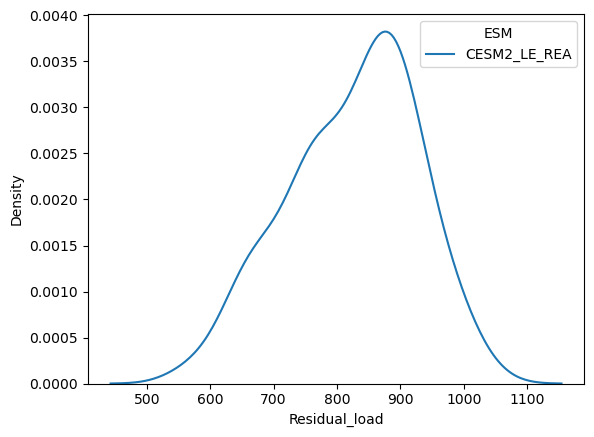

In [6]:
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure()
sns.kdeplot(
    data=df_REA,
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

In [7]:
# Flatten: combine all ESM_runs per season if needed
# values = ts_seasonal_mean.values.flatten()
values = df_REA['Residual_load'].values

# Sort descending
sorted_vals = np.sort(values)[::-1]

# Empirical probability (rank / total)
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

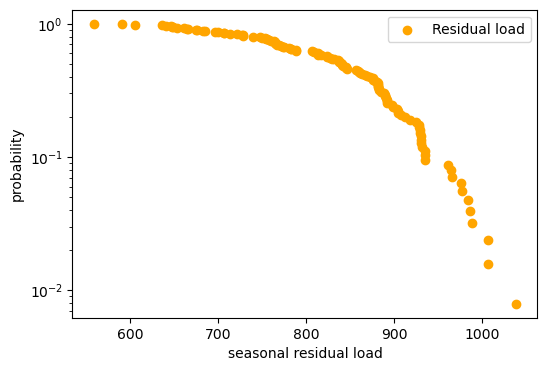

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(sorted_vals, prob, color="orange", label="Residual load")
plt.yscale("log")   # log-scale for probability
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend()
plt.show()

## meta obs

In [9]:
path = '/climca/people/onennecke/model_output/REA/*.nc'
files_lcl = [x for x in glob.glob(path) if x.endswith('.nc')]
ens_mems = [f"ens{i:03}" for i in range(1,127)]
diffs = []


for ens in ens_mems:
    matching_files = [f for f in files_lcl if ens in f]
    print(f"Processing {ens}")
    ds_REA_oi = xr.open_dataset(matching_files[0])
    ds_REA_oi.load()
    file = f"/climca/data/REA_output/RL_winter_DEU/NCAR/CESM2/ssp370-2025-x2/meta/obs/{ens}/obs__CESM2_ssp370-2025-x2_{ens}_2025.nc"
    ds_obs = xr.open_dataset(file)
    ds_obs.load()
    diff = ds_obs['obs'][:] - ds_REA_oi['Residual_load'][:]
    diffs.append(diff)
    # Close the datasets to free up memory
    ds_REA_oi.close()
    ds_obs.close()
    

Processing ens001
Processing ens002
Processing ens003
Processing ens004
Processing ens005
Processing ens006
Processing ens007
Processing ens008
Processing ens009
Processing ens010
Processing ens011
Processing ens012
Processing ens013
Processing ens014
Processing ens015
Processing ens016
Processing ens017
Processing ens018
Processing ens019
Processing ens020
Processing ens021
Processing ens022
Processing ens023
Processing ens024
Processing ens025
Processing ens026
Processing ens027
Processing ens028
Processing ens029
Processing ens030
Processing ens031
Processing ens032
Processing ens033
Processing ens034
Processing ens035
Processing ens036
Processing ens037
Processing ens038
Processing ens039
Processing ens040
Processing ens041
Processing ens042
Processing ens043
Processing ens044
Processing ens045
Processing ens046
Processing ens047
Processing ens048
Processing ens049
Processing ens050
Processing ens051
Processing ens052
Processing ens053
Processing ens054
Processing ens055
Processing

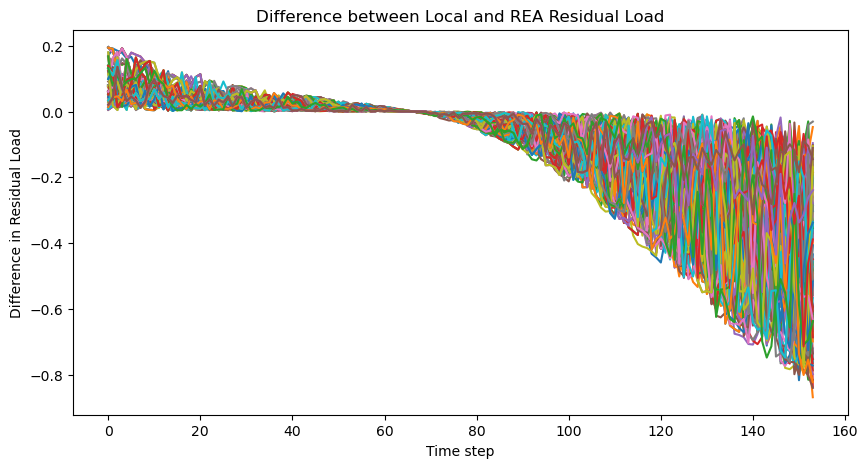

In [10]:
# Plot the difference
plt.figure(figsize=(10,5))
for i, diff in enumerate(diffs):
    plt.plot(diff, label=f'Difference (Local RL - REA RL) {ens_mems[i]}')
# plt.plot(diff, label='Difference (Local RL - REA RL)')
# plt.plot(wind_total, label='Local Wind')
# plt.plot(ds_REA_oi['solar_prod'][:], label='Local Solar')
plt.xlabel('Time step')
plt.ylabel('Difference in Residual Load')
plt.title('Difference between Local and REA Residual Load')
# plt.legend()
plt.show()


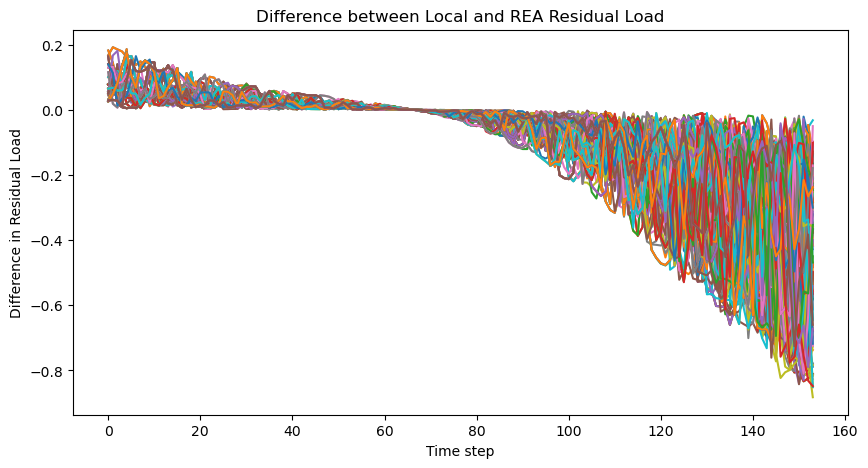

In [13]:
# Plot the difference
plt.figure(figsize=(10,5))
for i, diff in enumerate(diffs):
    plt.plot(diff, label=f'Difference (Local RL - REA RL) {ens_mems[i]}')
# plt.plot(diff, label='Difference (Local RL - REA RL)')
# plt.plot(wind_total, label='Local Wind')
# plt.plot(ds_REA_oi['solar_prod'][:], label='Local Solar')
plt.xlabel('Time step')
plt.ylabel('Difference in Residual Load')
plt.title('Difference between Local and REA Residual Load')
# plt.legend()
plt.show()


In [11]:
ds_REA_oi.time - ds_obs.time

<xarray.DataArray 'time' (time: 154)> Size: 1kB
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype='timedelta64[ns]')
Coordinates:
    sim       <U90 360B 'c2.124.124.124.124.124.125.125.125.125.125.125.125.1...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U12 48B 'CESM2_LE_REA'
    run       <U6 24B 'ens126'
    ESM_run   <U19 76B 'CESM2_LE_REA_ens126'
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [11]:
diff = ds_obs['obs'][:] - ds_REA_oi['Residual_load'][:]
print(diff.mean().values)
print(diff.std().values)
print(ds_obs.time.equals(ds_REA_oi.time))
print(ds_obs.time[:5].values)
print(ds_REA_oi.time[:5].values)
print(ds_obs.time.dt.calendar)
print(ds_REA_oi.time.dt.calendar)

-0.040023398634181015
0.08084202538634458
False
['2025-10-02T00:00:00.000000000' '2025-10-03T00:00:00.000000000'
 '2025-10-04T00:00:00.000000000' '2025-10-05T00:00:00.000000000'
 '2025-10-06T00:00:00.000000000']
['2025-10-02T00:00:00.000000000' '2025-10-03T00:00:00.000000000'
 '2025-10-04T00:00:00.000000000' '2025-10-05T00:00:00.000000000'
 '2025-10-06T00:00:00.000000000']
proleptic_gregorian
proleptic_gregorian


In [12]:
print(len(ds_obs.time))
print(len(ds_REA_oi.time))
print(ds_obs.time[-5:].values)
print(ds_REA_oi.time[-5:].values)
print(np.unique(np.diff(ds_obs.time.values)))
print(np.unique(np.diff(ds_REA_oi.time.values)))

154
154
['2026-02-28T00:00:00.000000000' '2026-03-01T00:00:00.000000000'
 '2026-03-02T00:00:00.000000000' '2026-03-03T00:00:00.000000000'
 '2026-03-04T00:00:00.000000000']
['2026-02-28T00:00:00.000000000' '2026-03-01T00:00:00.000000000'
 '2026-03-02T00:00:00.000000000' '2026-03-03T00:00:00.000000000'
 '2026-03-04T00:00:00.000000000']
[86400000000000]
[86400000000000]


In [11]:
path = '/climca/people/onennecke/model_output/REA/*.nc'
files_lcl = [x for x in glob.glob(path) if x.endswith('.nc')]
searched_ens = "ens061"
# searched_ens = "ens062"

matching_files = [f for f in files_lcl if searched_ens in f]
matching_files
ds_REA_oi = xr.open_dataset(matching_files[0])
ds_REA_oi.load()
print(matching_files[0])

: 

In [ ]:
path = '/climca/people/onennecke/model_output/REA/*.nc'
files_lcl = [x for x in glob.glob(path) if x.endswith('.nc')]

In [ ]:
ds_REA_oi = xr.open_dataset(files_lcl[0])

In [13]:
searched_ens = "ens061"


In [16]:
ds_REA_oi

<xarray.Dataset> Size: 15kB
Dimensions:        (time: 154)
Coordinates:
    sim            <U90 360B 'c2.124.124.124.124.124.125.125.125.125.125.125....
  * time           (time) datetime64[ns] 1kB 2025-10-02 ... 2026-03-04
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U12 48B 'CESM2_LE_REA'
    run            <U6 24B 'ens126'
    ESM_run        <U19 76B 'CESM2_LE_REA_ens126'
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (time) float64 1kB 6.649 6.014 7.317 ... 8.055 5.688 4.226
    demand         (time) float64 1kB 1.437e+03 1.445e+03 ... 1.468e+03
    sfcWind        (time) float64 1kB 5.708 6.62 6.96 ... 10.83 7.547 5.048
    rsds           (time) float32 616B 34.95 47.69 70.86 ... 87.1 82.89 94.04
    tas            (time) float32 616B 7.035 6.134 7.651 ... 7.781 5.239 3.865
    tasmax         (time) float32 616B 8.531 7.99 12.15 ... 9.719 6.948 5.621
    wind_off_prod  (time) float64 1kB 50.29 52.76 156.6 ... 112.8 66.37 53.08
    wind_on_prod   (time) float64 1kB 251.3 337.0 426.1 ... 402.8 185.0
    solar_prod     (time) float64 1kB 51.15 70.3 128.5 ... 105.5 120.0 147.6
    total_prod     (time) float64 1kB 352.8 460.1 711.2 ... 589.1 385.7
    Netto          (time) float64 1kB -1.084e+03 -984.9 ... -860.0 -1.082e+03
    Residual_load  (time) float64 1kB 1.084e+03 984.9 717.1 ... 860.0 1.082e+03

In [14]:
file = f"/climca/data/REA_output/RL_winter_DEU/NCAR/CESM2/ssp370-2025-x2/meta/obs/{searched_ens}/obs__CESM2_ssp370-2025-x2_{searched_ens}_2025.nc"
ds_obs = xr.open_dataset(file)
ds_obs.load()

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 154)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
    sim       <U90 360B 'c2.040.037.036.034.035.040.043.045.044.044.046.043.0...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
Data variables:
    obs       (time) float64 1kB 344.7 425.3 257.2 62.6 ... 720.1 901.3 980.0
Attributes: (12/15)
    Conventions:             CF-1.0
    source:                  CAM
    case:                    c2_060
    logname:                 u290372
    host:                    
    initial_file:            /work/bb1152/u290372/cesm215_input_data/atm/cam/...
    ...                      ...
    simulation_name:         c2.040.037.036.034.035.040.043.045.044.044.046.0...
    initial_condition:       /work/bb1152/u290372/cesm215_archive/GKLT/prep_s...
    initial_condition_year:  ens009_2024
    compset:                 BSSP370cmip6
    readme:                  https://github.com/peterpeterp/REA_low_energy_wi...
    preprocessing:           regional average over region of interest

In [15]:
print(ds_REA_oi['Residual_load'].sum().values)
print(ds_obs['obs'].sum().values)

93278.55587561142
117709.24038743548


In [ ]:
157406.43120236642 - 157395.88305754558


10.548144820844755

In [15]:
157406.43120236642 /100

1574.0643120236643

In [64]:
print(ds_REA_oi['Residual_load'].sum().values)
print(ds_obs['obs'].sum().values)

157400.6613138067
187846.00018108136


In [33]:
# calculate rolling mean of 5 for ds_REA_oi['Residual_load']
rl_REA_oi = ds_REA_oi['Residual_load'].rolling(time=5, center=True).mean()

In [12]:
wind_total = ds_REA_oi['wind_on_prod'][:] + ds_REA_oi['wind_off_prod'][:]

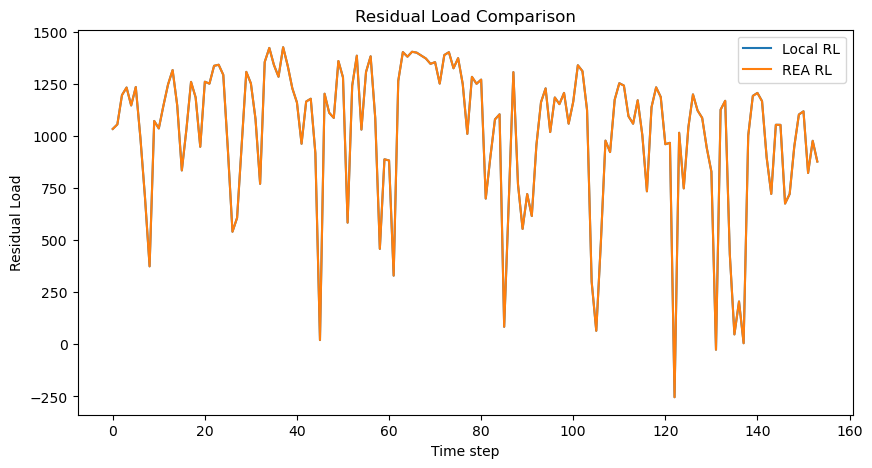

In [24]:
# Plot ds_REA_ens001['Residual_load'] and ds_obs['Residual_load'] for the first 100 time steps
plt.figure(figsize=(10,5))
plt.plot(ds_REA_oi['Residual_load'][:], label='Local RL')

plt.plot(ds_obs['obs'][:], label='REA RL')
# plt.plot(wind_total, label='Local Wind', linestyle='--')

# plt.plot(rl_REA_oi[:], label='REA Ens061 (Rolling Mean)', linestyle='--')

plt.xlabel('Time step')
plt.ylabel('Residual Load')
plt.title('Residual Load Comparison')
plt.legend()
plt.show()

## All obs

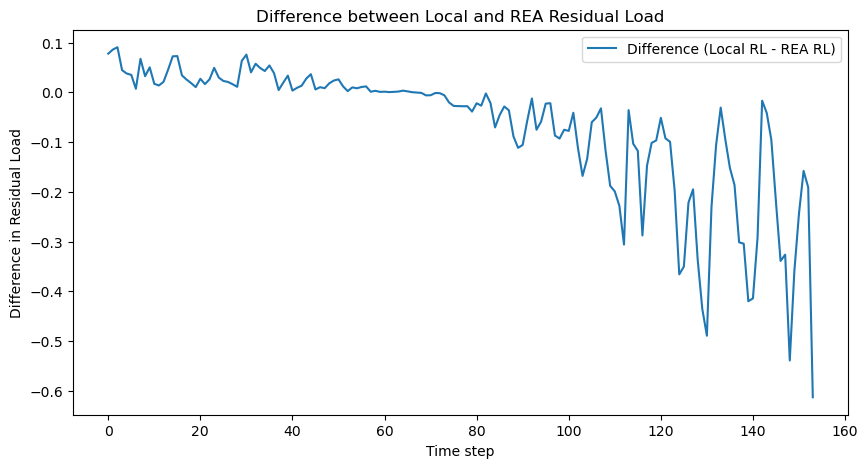

In [25]:
diff = ds_obs['obs'][:] - ds_REA_oi['Residual_load'][:]
# Plot the difference
plt.figure(figsize=(10,5))
plt.plot(diff, label='Difference (Local RL - REA RL)')
# plt.plot(wind_total, label='Local Wind')
# plt.plot(ds_REA_oi['solar_prod'][:], label='Local Solar')
plt.xlabel('Time step')
plt.ylabel('Difference in Residual Load')
plt.title('Difference between Local and REA Residual Load')
plt.legend()
plt.show()


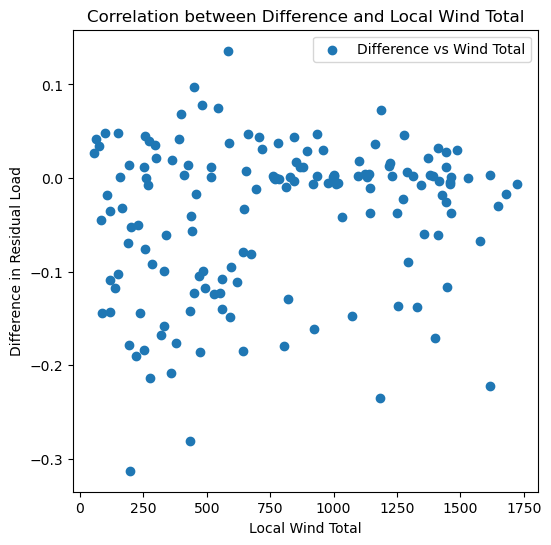

In [13]:
# Plot correlation between the difference and the wind total
plt.figure(figsize=(6,6))
plt.scatter(wind_total, diff, label='Difference vs Wind Total')
plt.xlabel('Local Wind Total')
plt.ylabel('Difference in Residual Load')
plt.title('Correlation between Difference and Local Wind Total')
plt.legend()
plt.show()

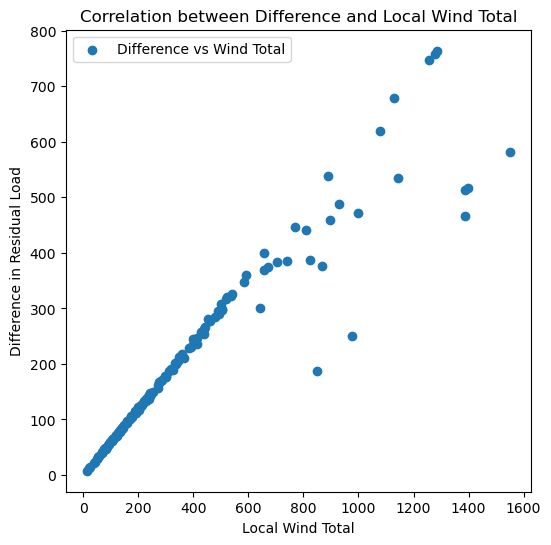

In [68]:
# Plot correlation between the difference and the wind total
plt.figure(figsize=(6,6))
plt.scatter(wind_total, diff, label='Difference vs Wind Total')
plt.xlabel('Local Wind Total')
plt.ylabel('Difference in Residual Load')
plt.title('Correlation between Difference and Local Wind Total')
plt.legend()
plt.show()

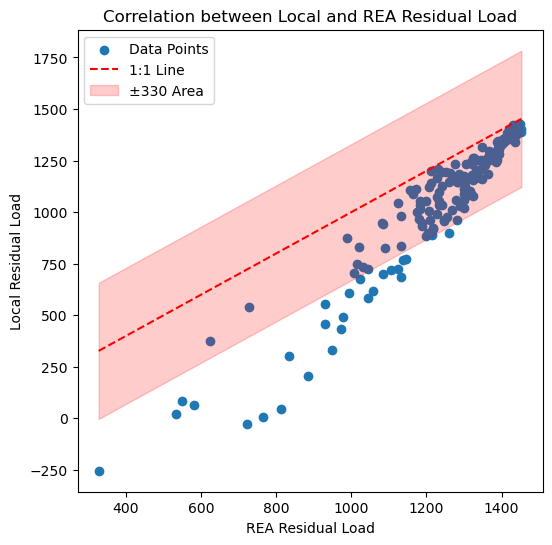

In [75]:
# Plot correlation between the difference and the wind total
plt.figure(figsize=(6,6))
plt.scatter(ds_obs['obs'][:], ds_REA_oi['Residual_load'][:],label='Data Points')
# Plot 1:1 line
plt.plot([ds_obs['obs'][:].min(), ds_obs['obs'][:].max()], [ds_obs['obs'][:].min(), ds_obs['obs'][:].max()], color='red', linestyle='--', label='1:1 Line')
# Plot a area around the 1:1 line
plt.fill_between([ds_obs['obs'][:].min(), ds_obs['obs'][:].max()], [ds_obs['obs'][:].min()-330, ds_obs['obs'][:].max()-330], [ds_obs['obs'][:].min()+330, ds_obs['obs'][:].max()+330], color='red', alpha=0.2, label='±330 Area')
plt.xlabel('REA Residual Load')
plt.ylabel('Local Residual Load')
plt.title('Correlation between Local and REA Residual Load')
plt.legend()
plt.show()

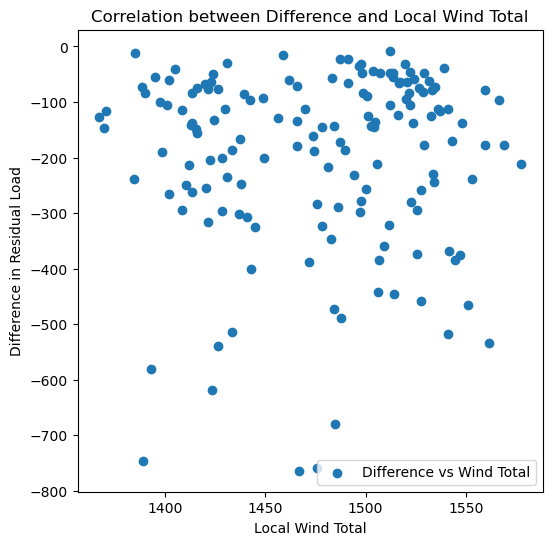

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(ds_REA_oi['demand'][:], diff, label='Difference vs Wind Total')
plt.xlabel('Local Wind Total')
plt.ylabel('Difference in Residual Load')
plt.title('Correlation between Difference and Local Wind Total')
plt.legend()
plt.show()

In [14]:
path = "/climca/data/REA_output/RL_winter_DEU/NCAR/CESM2/ssp370-2025-x2/meta/obs/ens*/*.nc"
files = [x for x in glob.glob(path) if x.endswith('.nc')]
ds_obs_all = xr.open_mfdataset(files, combine='nested', concat_dim='sim')
ds_obs_all.load()

<xarray.Dataset> Size: 202kB
Dimensions:   (sim: 126, time: 154)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * sim       (sim) <U90 45kB 'c2.069.067.067.064.066.069.069.068.068.069.072...
  * time      (time) datetime64[ns] 1kB 2025-10-02 2025-10-03 ... 2026-03-04
Data variables:
    obs       (sim, time) float64 155kB 20.04 149.1 -322.1 ... 1.043e+03 940.2
Attributes: (12/15)
    Conventions:             CF-1.0
    source:                  CAM
    case:                    c2_074
    logname:                 u290372
    host:                    
    initial_file:            /work/bb1152/u290372/cesm215_input_data/atm/cam/...
    ...                      ...
    simulation_name:         c2.069.067.067.064.066.069.069.068.068.069.072.0...
    initial_condition:       /work/bb1152/u290372/cesm215_archive/GKLT/prep_s...
    initial_condition_year:  ens013_2026
    compset:                 BSSP370cmip6
    readme:                  https://github.com/peterpeterp/REA_low_energy_wi...
    preprocessing:           regional average over region of interest

In [15]:
ens_sim_dict = {}
for file in files:
    
    ens = file.split('/')[-2]  # Extract ensemble name from file path
    # print(f"Processing {ens} from file: {file}")
    ds = xr.open_dataset(file)
    sim = ds['sim']
    # Store the sim value in the dictionary with ensemble name as key
    ens_sim_dict[str(sim.values)] = ens
    

In [16]:
# Add ensemble coordinate to ds_obs_all depending on the sim values in the ens_sim_dict
mapped = [ens_sim_dict.get(str(x), "Unknown") for x in ds_obs_all['sim'].values]

ds_obs_all = ds_obs_all.assign_coords(
    ensemble=('sim', mapped)
)

# ds_obs_all['ensemble']

In [17]:
ds_obs_all_seasonal_mean = ds_obs_all['obs'].mean('time')
ds_obs_all_seasonal_mean

<xarray.DataArray 'obs' (sim: 126)> Size: 1kB
array([ 739.34795749,  813.08072546,  965.18799216,  861.39553425,
        841.19342106,  875.76587925,  727.1372088 ,  682.62768172,
        902.94457166,  605.66488488,  763.20439374,  720.8944032 ,
        884.9328251 ,  840.72903432,  674.58046364,  835.99092816,
        904.42388901,  750.13809416,  646.00394242,  964.02460832,
        808.99837161,  929.34276212,  727.73242842,  875.62473218,
        859.85500696,  765.75748755,  675.90656682,  845.54782155,
        764.3457168 ,  930.68293351,  813.68075444,  836.97795702,
        831.06291645,  904.55240745,  558.40082401,  844.55161561,
        823.55593805,  896.80751728,  780.12327465,  829.56170271,
        746.85094351,  891.18078503,  727.8154914 ,  983.62690906,
        788.49374992,  866.62492415,  706.41035957,  934.2789102 ,
        930.63747686,  856.74726511,  590.66768118,  783.0995886 ,
        648.98159131,  764.04641971,  907.78956233,  912.63342522,
        927.83023519,  699.8687883 ,  985.70107346,  653.61960608,
        898.71955902,  975.85187827,  766.47702053,  760.30391667,
        660.9737302 ,  929.44409783,  988.20539021,  773.30918202,
        880.69896347,  928.56822767,  713.27581761,  889.60306858,
        839.45427019,  960.73660977,  753.08768996,  882.34408034,
        813.62466285,  917.91496912,  881.76395637,  806.68540436,
        769.34912053,  881.64833229,  924.14157417,  705.94329998,
        755.74261417,  782.11878445,  877.73768073,  858.96745708,
        757.47403552,  976.92224559,  823.43753518,  764.97345963,
        774.66905516,  881.47620406,  930.4316381 ,  888.9737828 ,
        840.68940097,  869.11384995,  685.27904522,  647.98766599,
        696.39663824,  934.31576406,  788.75583959,  888.65977142,
        890.77817682,  636.02728507,  816.11574304,  863.0388204 ,
        934.96948299, 1005.87614105,  664.88598621,  882.20879188,
        846.41154109,  771.45826829,  891.8543996 ,  881.94796904,
        836.97964054,  891.74085062, 1038.56085073,  754.60301021,
       1006.09489424,  930.92191463,  872.0692726 ,  665.56125141,
        640.48777887,  826.58073226])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * sim       (sim) <U90 45kB 'c2.069.067.067.064.066.069.069.068.068.069.072...
    ensemble  (sim) <U6 3kB 'ens075' 'ens031' 'ens095' ... 'ens021' 'ens072'

In [18]:
#Find out which ensemble is the maximum value in ds_obs_all_seasonal_mean
max_value = ds_obs_all_seasonal_mean.max().values
max_ensemble = ds_obs_all_seasonal_mean.where(ds_obs_all_seasonal_mean == max_value, drop=True)['ensemble'].values
print(f"Maximum value: {max_value}, Ensemble: {max_ensemble}")

# Second highest value
second_max_value = ds_obs_all_seasonal_mean.where(ds_obs_all_seasonal_mean < max_value).max().values
second_max_ensemble = ds_obs_all_seasonal_mean.where(ds_obs_all_seasonal_mean == second_max_value, drop=True)['ensemble'].values
print(f"Second highest value: {second_max_value}, Ensemble: {second_max_ensemble}")

Maximum value: 1038.5608507264185, Ensemble: ['ens029']
Second highest value: 1006.0948942437299, Ensemble: ['ens028']


In [19]:
# Flatten: combine all ESM_runs per season if needed
# values = ts_seasonal_mean.values.flatten()
values = ds_obs_all_seasonal_mean.values

# Sort descending
sorted_vals_REA = np.sort(values)[::-1]

# Empirical probability (rank / total)
prob_REA = np.arange(1, len(sorted_vals_REA)+1) / len(sorted_vals_REA)

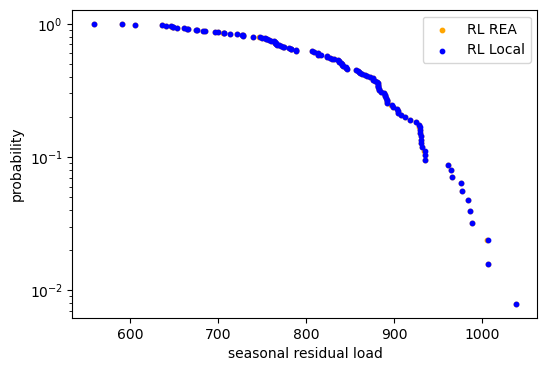

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(sorted_vals_REA, prob_REA, color="orange", label="RL REA", s=10)
plt.scatter(sorted_vals, prob, color="blue", label="RL Local", s=10)

plt.yscale("log")   # log-scale for probability
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend()
plt.show()

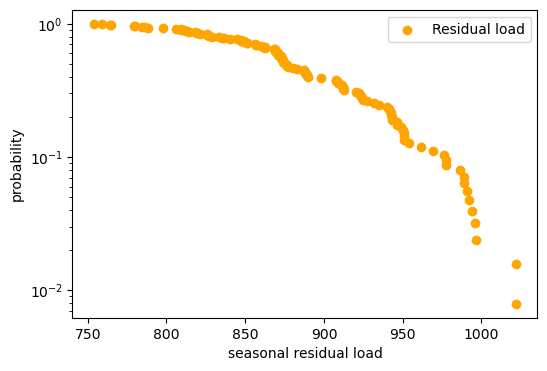

In [37]:
# Flatten: combine all ESM_runs per season if needed
# values = ts_seasonal_mean.values.flatten()
values = df_REA['Residual_load'].values

# Sort descending
sorted_vals = np.sort(values)[::-1]

# Empirical probability (rank / total)
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
plt.figure(figsize=(6,4))
plt.scatter(sorted_vals, prob, color="orange", label="Residual load")
plt.yscale("log")   # log-scale for probability
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend()
plt.show()